<a href="https://colab.research.google.com/github/AbhishekShah272002/Gen_AI_Computer_Vision_Work/blob/main/Compare_Activation_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, LeakyReLU
import matplotlib.pyplot as plt

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [5]:
x_train = x_train.reshape(-1,28,28,1).astype('float32')/255.0
x_test = x_test.reshape(-1,28,28,1).astype('float32')/255.0

In [6]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Training model with RELU activation
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.9363 - loss: 0.2246 - val_accuracy: 0.9746 - val_loss: 0.0867
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9804 - loss: 0.0681 - val_accuracy: 0.9804 - val_loss: 0.0594
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.9864 - loss: 0.0474 - val_accuracy: 0.9811 - val_loss: 0.0541
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.9897 - loss: 0.0342 - val_accuracy: 0.9847 - val_loss: 0.0469
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.9924 - loss: 0.0256 - val_accuracy: 0.9839 - val_loss: 0.0464
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9937 - loss: 0.0206 - val_accuracy: 0.9836 - val_loss: 0.0540
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9959 - loss: 0.0142 - val_accuracy: 0.9858 - val_loss: 0.0460
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 65ms/step 

KeyError: 'sigmoid'

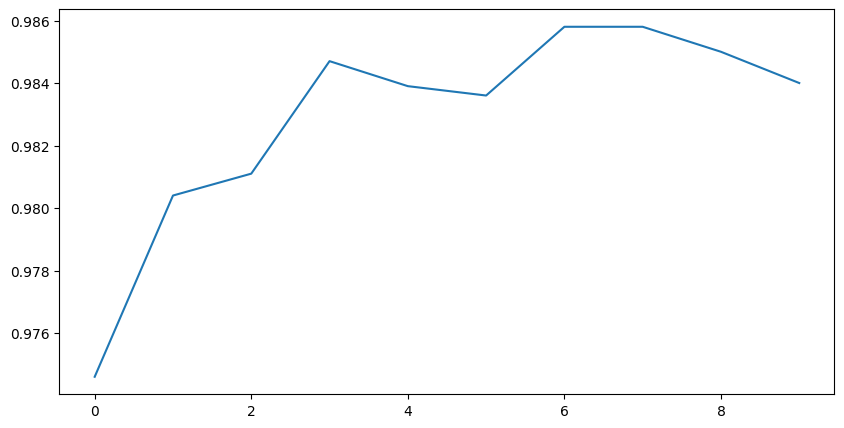

In [11]:
def build_model(activation_type):
  model = Sequential()

  model.add(Input(shape=(28,28,1)))

  model.add(Conv2D(32, (3,3)))
  if activation_type == 'leakyrelu':
    model.add(LeakyReLU(alpha=0.1))
  else:
    model.add(tf.keras.layers.Activation(activation_type))

  model.add(MaxPooling2D((2,2)))
  model.add(Flatten())
  model.add(Dense(128))
  if activation_type == 'leakyrelu':
    model.add(LeakyReLU(alpha=0.3))
  else:
      model.add(tf.keras.layers.Activation(activation_type))

  model.add(Dense(10, activation='softmax'))

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

activation = ['relu', 'sigmoid', 'leakyrelu']
histories = {}

for act in activation:
  print(f'Training model with {act.upper()} activation')
  model = build_model(act)
  history = model.fit(x_train, y_train, epochs=10, batch_size=128,
                      validation_data=(x_test, y_test), verbose=1)
  histories[act] = history

  plt.figure(figsize=(10,5))
  for act in activation:
     plt.plot(histories[act].history['val_accuracy'], label=act.upper())
  plt.title('Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Validation')
  plt.legend()
  plt.grid(True)
  plt.show()

KeyError: 'sigmoid'

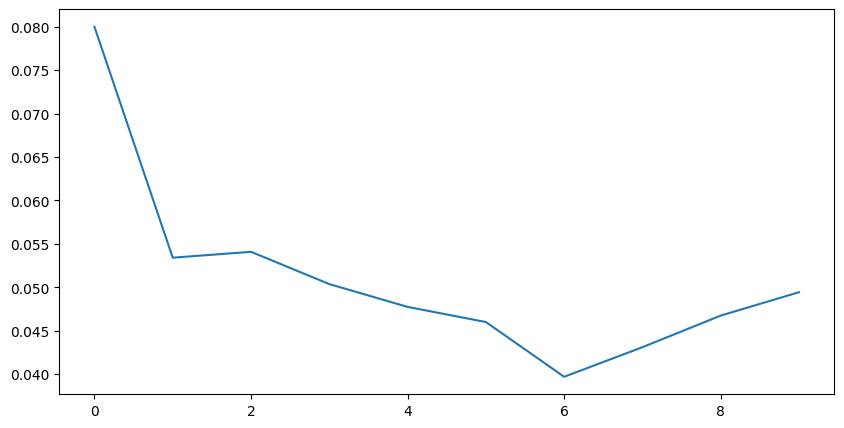

In [10]:
plt.figure(figsize=(10,5))
for act in activation:
   plt.plot(histories[act].history['val_loss'], label = act.upper())
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()